In [97]:
# 1. 数据基础库
%pip install numpy pandas

# 2. 可视化库
%pip install matplotlib seaborn

# 3. 机器学习库
%pip install scikit-learn

# 4. 统计分析库
%pip install statsmodels scipy

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'd:\modeling\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'd:\modeling\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'd:\modeling\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'd:\modeling\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


In [98]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import integrate
import time

# 设置中文字体和随机种子
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
np.random.seed(42)

In [99]:
print("\n" + "="*60)
print("练习二：复杂函数的蒙特卡洛积分")
print("Exercise 2: Monte Carlo Integration of Complex Functions")
print("="*60)


练习二：复杂函数的蒙特卡洛积分
Exercise 2: Monte Carlo Integration of Complex Functions


In [100]:
def target_function(x):
    """
    目标函数: f(x) = e^(-x²) * sin(x)
    这是一个没有简单解析解的函数
    """
    return np.exp(-x**2) * np.sin(x)

def monte_carlo_integral(func, a, b, n):
    """
    蒙特卡洛积分计算
    
    参数:
        func: 被积函数
        a, b: 积分下限和上限
        n: 随机样本数量
    
    返回:
        integral: 积分估计值
        std_error: 标准误差
        samples: 样本点
        func_values: 函数值
    """
    # 生成随机样本
    samples = np.random.uniform(a, b, n)

    # 计算函数值
    func_values = func(samples)

    # 蒙特卡洛积分估计
    integral = (b - a) * np.mean(func_values)

    # 标准差估计
    std_error = (b - a) * np.std(func_values) / np.sqrt(n)

    return integral, std_error, samples, func_values

2.1函数可视化


2.1函数可视化


d:\modeling\.venv\lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  func(*args, **kwargs)
d:\modeling\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


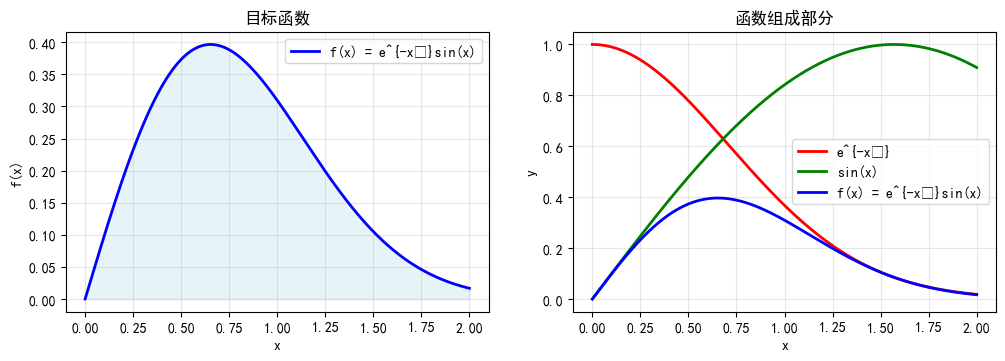

In [101]:
print('\n2.1函数可视化')
x_plot = np.linspace(0,2,1000)
y_plot = target_function(x_plot)

plt.figure(figsize=(12,8))

# 子图1：函数图像
plt.subplot(2,2,1)
plt.plot(x_plot, y_plot, 'b-', linewidth=2, label='f(x) = e^{-x²}sin(x)')
plt.fill_between(x_plot, 0, y_plot, alpha=0.3, color='lightblue')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('目标函数')
plt.legend()
plt.grid(True, alpha=0.3)


# 子图2：函数组成部分
plt.subplot(2,2,2)
plt.plot(x_plot, np.exp(-x_plot**2), 'r-', linewidth=2, label='e^{-x²}')
plt.plot(x_plot, np.sin(x_plot), 'g-', linewidth=2, label='sin(x)')
plt.plot(x_plot, y_plot, 'b-', linewidth=2, label='f(x) = e^{-x²}sin(x)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('函数组成部分')
plt.legend()
plt.grid(True, alpha=0.3)

2.2单次积分计算

In [102]:
print('\n2.2单次蒙特卡洛积分计算')
a, b = 0, 2  # 积分区间
n_samples = 100000

integral_mc, error_mc, samples, func_vals = monte_carlo_integral(target_function, a, b, n_samples)

# 使用scipy进行数值积分作为参考————Scipy 的 QUADPACK 自适应数值积分，基于高斯-克朗罗德求积法
integral_scipy, _ = integrate.quad(target_function, a, b)

print(f"积分区间: [{a}, {b}]")
print(f"样本数量: {n_samples}")
print(f"蒙特卡洛估计: {integral_mc:.6f} ± {error_mc:.6f}")
print(f"Scipy数值积分: {integral_scipy:.6f}")
print(f"绝对误差: {abs(integral_mc - integral_scipy):.6f}")
print(f"相对误差: {abs(integral_mc - integral_scipy)/abs(integral_scipy)*100:.3f}%")


2.2单次蒙特卡洛积分计算
积分区间: [0, 2]
样本数量: 100000
蒙特卡洛估计: 0.421431 ± 0.000830
Scipy数值积分: 0.421164
绝对误差: 0.000267
相对误差: 0.063%


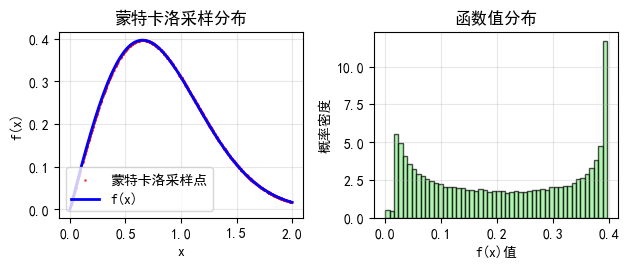

In [103]:
# 子图3：蒙特卡洛采样点
plt.subplot(2,2,3)
sample_subset = samples[:1000]  # 只显示前一千个
func_subset = func_vals[:1000]
plt.scatter(sample_subset, func_subset, c='red', s=1, alpha=0.6, label='蒙特卡洛采样点')
plt.plot(x_plot, y_plot, 'b-', linewidth=2, label='f(x)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('蒙特卡洛采样分布')
plt.legend()
plt.grid(True, alpha=0.3)

# 子图4：函数值分布
plt.subplot(2,2,4)
plt.hist(func_vals, bins=50, density=True, alpha=0.7, color='lightgreen', edgecolor='black')
plt.xlabel('f(x)值')
plt.ylabel('概率密度')
plt.title('函数值分布')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

2.3 收敛性分析

In [104]:
print('\n2.3积分收敛性分析')

def integral_convergence_analysis(func, a, b, max_n=100000, step=5000):
    """分析积分估计的收敛过程"""
    n_values = range(step,max_n+1,step)
    integrals = []
    errors = []

    # 一次性生成所有随机数
    all_samples = np.random.uniform(a, b, max_n)
    all_func_values = func(all_samples)

    for n in n_values:
        current_samples = all_func_values[:n]
        integral_est = (b-a) * np.mean(current_samples)
        std_err = (b-a) * np.std(current_samples) / np.sqrt(n)

        integrals.append(integral_est)
        errors.append(std_err)

    return n_values, integrals, errors

n_vals_int, integrals_int, errors_int = integral_convergence_analysis(target_function,a,b)


2.3积分收敛性分析


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

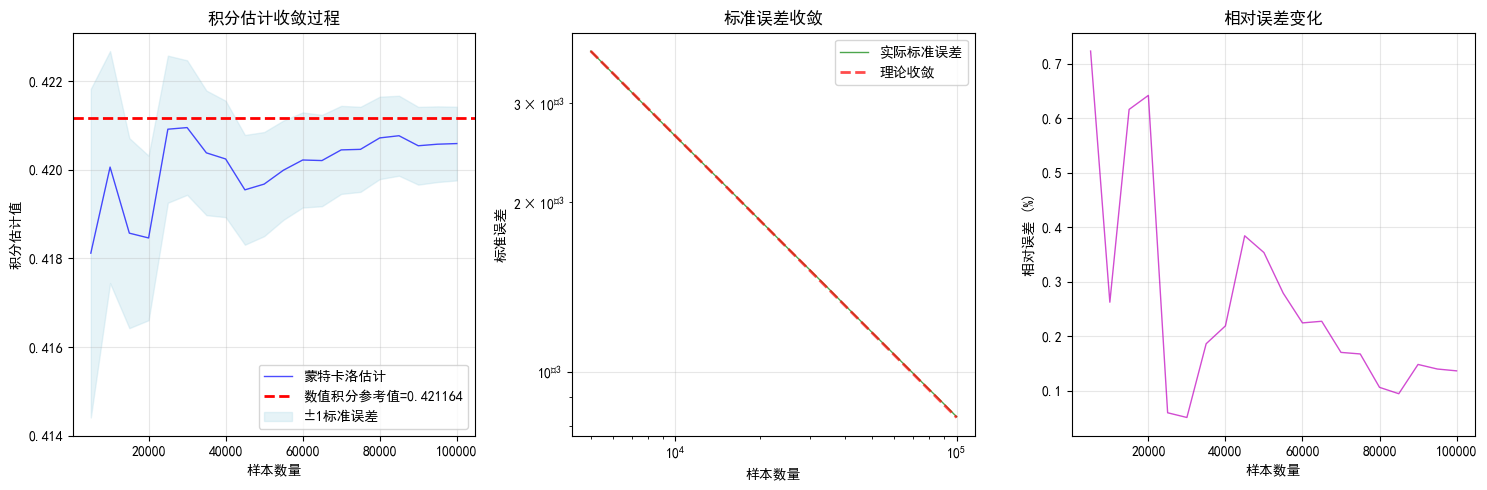

In [105]:
# 绘制收敛过程
plt.figure(figsize=(15,5))

# 积分值收敛
plt.subplot(1,3,1)
plt.plot(n_vals_int, integrals_int, 'b-', linewidth=1, alpha=0.7, label='蒙特卡洛估计')
plt.axhline(y=integral_scipy, color='r', linestyle='--', linewidth=2,label=f'数值积分参考值={integral_scipy:.6f}')
# 列表不支持减法————np.array(integrals_int) - np.array(errors_int)
plt.fill_between(n_vals_int, 
                 np.array(integrals_int) - np.array(errors_int),
                 np.array(integrals_int) + np.array(errors_int),
                 alpha=0.3, color='lightblue', label='±1标准误差')
plt.xlabel('样本数量')
plt.ylabel('积分估计值')
plt.title('积分估计收敛过程')
plt.legend()
plt.grid(True, alpha=0.3)

# 标准误差变化
plt.subplot(1,3,2)
plt.plot(n_vals_int, errors_int, 'g-', linewidth=1, alpha=0.7, label='实际标准误差')
plt.plot(n_vals_int, errors_int[0] * np.sqrt(n_vals_int[0]) / np.sqrt(n_vals_int),
         'r--', linewidth=2, alpha=0.7, label='理论收敛')
plt.xlabel('样本数量')
plt.ylabel('标准误差')
plt.title('标准误差收敛')
plt.legend()
plt.grid(True, alpha=0.3)
# 轴的对数坐标，更直观（斜率为-0.5）
plt.yscale('log')
plt.xscale('log')

# 相对误差
plt.subplot(1, 3, 3)
rel_errors = [abs(est - integral_scipy)/abs(integral_scipy)*100 for est in integrals_int]
plt.plot(n_vals_int, rel_errors, 'm-', linewidth=1, alpha=0.7)
plt.xlabel('样本数量')
plt.ylabel('相对误差 (%)')
plt.title('相对误差变化')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

2.4不同积分方法比较

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.



2.4 不同数值积分方法比较
不同样本量的计算结果比较:
      样本数    蒙特卡洛估计      标准误差      绝对误差   相对误差(%)   计算时间(秒)
0    1000  0.424412  0.008181  0.003247  0.771030  0.000000
1    5000  0.418292  0.003717  0.002873  0.682092  0.000000
2   10000  0.422416  0.002624  0.001252  0.297222  0.000000
3   50000  0.420951  0.001178  0.000213  0.050676  0.001000
4  100000  0.421240  0.000831  0.000075  0.017900  0.001997


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


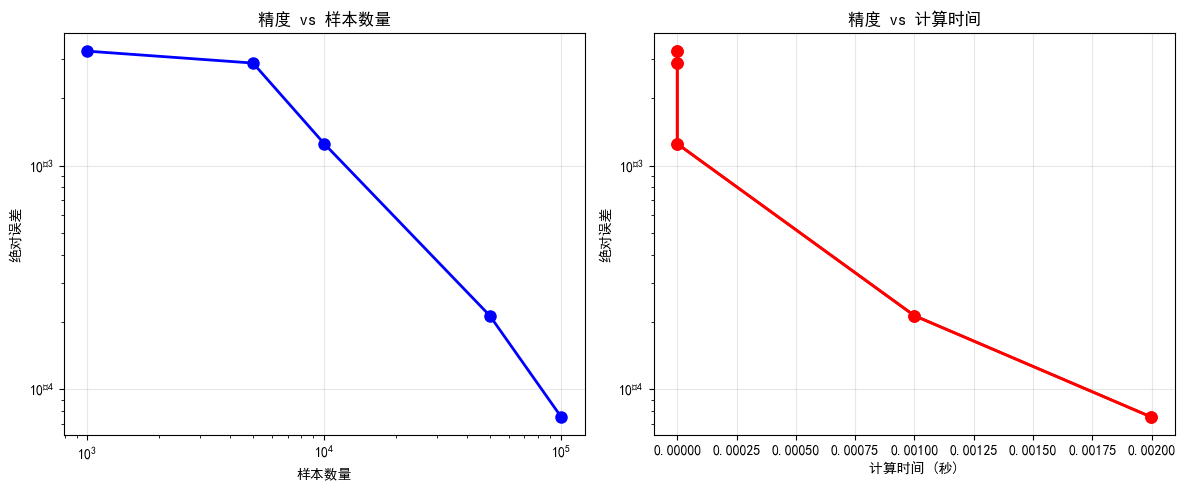

In [106]:
print("\n2.4 不同数值积分方法比较")

# 比较不同样本量下的计算时间和精度

sample_sizes = [1000,5000,10000,50000,100000]
results_comprison = []

for n in sample_sizes:
    start_time = time.time()
    mc_result, mc_error,_,_ = monte_carlo_integral(target_function,a,b,n)
    mc_time = time.time() - start_time

    # 计算与参考值的误差
    mc_abs_error = abs(mc_result - integral_scipy)

    results_comprison.append({
        '样本数': n,
        '蒙特卡洛估计': mc_result,
        '标准误差': mc_error,
        '绝对误差': mc_abs_error,
        '相对误差(%)': mc_abs_error/abs(integral_scipy)*100,
        '计算时间(秒)': mc_time
    })

# 创建DataFrame
df_comparison = pd.DataFrame(results_comprison)
print("不同样本量的计算结果比较:")
print(df_comparison.round(6))

# 绘制精度与计算时间
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
# 双对数坐标，x轴和y轴都取对数 
plt.loglog(df_comparison['样本数'], df_comparison['绝对误差'], 'bo-', linewidth=2, markersize=8)
plt.xlabel('样本数量')
plt.ylabel('绝对误差')
plt.title('精度 vs 样本数量')
plt.grid(True, alpha=0.3)


plt.subplot(1,2,2)
plt.plot(df_comparison['计算时间(秒)'], df_comparison['绝对误差'], 'ro-', linewidth=2, markersize=8)
plt.subplot(1, 2, 2)
plt.plot(df_comparison['计算时间(秒)'], df_comparison['绝对误差'], 'ro-', linewidth=2, markersize=8)
plt.xlabel('计算时间 (秒)')
plt.ylabel('绝对误差')
plt.title('精度 vs 计算时间')
plt.grid(True, alpha=0.3)
plt.yscale('log')

plt.tight_layout()
plt.show()


2.5 置信区间分析

In [107]:
print("\n2.5 置信区间分析")

def confidence_interval(func,a,b,n,confidence_level=0.95,n_trials=50):
    """
    进行多次独立试验，分析置信区间的覆盖率
    
    参数:
        func: 被积函数
        a, b: 积分区间
        n: 每次试验的样本数
        confidence_level: 置信水平
        n_trials: 试验次数
    """
    from scipy.stats import norm

    # 计算置信区间的z值
    alpha = 1 - confidence_level
    z_value = norm.ppf(1 - alpha/2)  # 取正态分布中间的95%

    results = []
    coverage_count = 0

    reference_value, _ = integrate.quad(func, a, b)

    for trial in range(n_trials):
        integral_est, std_error, _, _ = monte_carlo_integral(func,a,b,n)

        # 计算置信区间（中心极限定理，蒙特卡洛估计量近似正态分布）
        lower_bound = integral_est - z_value * std_error
        upper_bound = integral_est + z_value * std_error

        # 检查是否覆盖真实值
        covers_true_value = lower_bound <= reference_value <= upper_bound
        if covers_true_value:
            coverage_count += 1

        results.append({
            '试验': trial + 1,
            '积分估计': integral_est,
            '下界': lower_bound,
            '上界': upper_bound,
            '区间宽度': upper_bound - lower_bound,
            '覆盖真值': covers_true_value
        })

    coverage_rate = coverage_count / n_trials

    return results, coverage_rate, reference_value


2.5 置信区间分析


In [108]:
ci_results, coverage_rate, ref_val = confidence_interval(
    target_function,a,b,n=10000,confidence_level=0.95,n_trials=50
)

print(f"95%置信区间分析结果 (基于{len(ci_results)}次独立试验):")
print(f"理论覆盖率: 95%")
print(f"实际覆盖率: {coverage_rate*100:.1f}%")
print(f"参考积分值: {ref_val:.6f}")

95%置信区间分析结果 (基于50次独立试验):
理论覆盖率: 95%
实际覆盖率: 98.0%
参考积分值: 0.421164


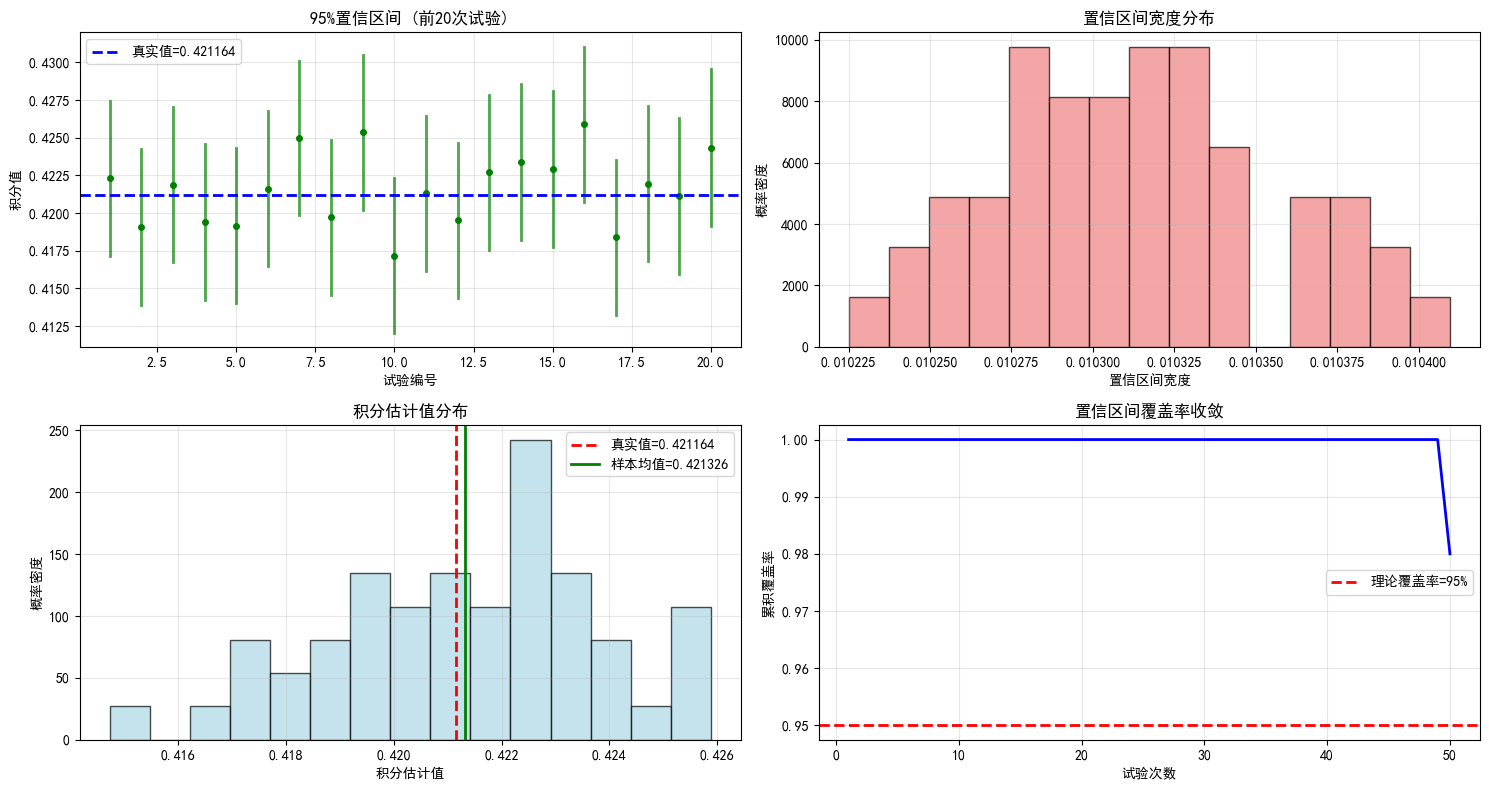

In [109]:
# 可视化置信区间
plt.figure(figsize=(15, 8))

# 子图1：置信区间可视化
plt.subplot(2,2,1)
trial_nums = [r['试验'] for r in ci_results[:20]]  #只显示前20个
estimates = [r['积分估计'] for r in ci_results[:20]]
lower_bounds = [r['下界'] for r in ci_results[:20]]
upper_bounds = [r['上界'] for r in ci_results[:20]]
covers = [r['覆盖真值'] for r in ci_results[:20]]
# zip将5个列表按位置打包，每次迭代取各列表的对应元素   enumerate返回 (索引, 元组) ，即  (i, (trial, est, lower, upper, cover)) 
for i,(trial, est, lower, upper, cover) in enumerate(zip(trial_nums, estimates, lower_bounds, upper_bounds, covers)):
    color = 'green' if cover else 'red'
    plt.plot([trial,trial], [lower,upper], color=color, linewidth=2, alpha=0.7)
    plt.plot(trial,est,'o', color=color, markersize=4)
plt.axhline(y=ref_val, color='blue', linestyle='--', linewidth=2, label=f'真实值={ref_val:.6f}')
plt.xlabel('试验编号')
plt.ylabel('积分值')
plt.title('95%置信区间 (前20次试验)')
plt.legend()
plt.grid(True, alpha=0.3)

# 子图2：区间宽度分布
plt.subplot(2, 2, 2)
widths = [r['区间宽度'] for r in ci_results]
plt.hist(widths, bins=15, density=True, alpha=0.7, color='lightcoral', edgecolor='black')
plt.xlabel('置信区间宽度')
plt.ylabel('概率密度')
plt.title('置信区间宽度分布')
plt.grid(True, alpha=0.3)

# 子图3：估计值分布
plt.subplot(2, 2, 3)
all_estimates = [r['积分估计'] for r in ci_results]
plt.hist(all_estimates, bins=15, density=True, alpha=0.7, color='lightblue', edgecolor='black')
plt.axvline(ref_val, color='red', linestyle='--', linewidth=2, label=f'真实值={ref_val:.6f}')
plt.axvline(np.mean(all_estimates), color='green', linestyle='-', linewidth=2, 
           label=f'样本均值={np.mean(all_estimates):.6f}')
plt.xlabel('积分估计值')
plt.ylabel('概率密度')
plt.title('积分估计值分布')
plt.legend()
plt.grid(True, alpha=0.3)

# 子图4：覆盖率随试验次数变化
plt.subplot(2, 2, 4)
cumulative_coverage = []
cumulative_count = 0
for i, result in enumerate(ci_results):
    if result['覆盖真值']:
        cumulative_count += 1
    cumulative_coverage.append(cumulative_count / (i + 1))

plt.plot(range(1, len(ci_results) + 1), cumulative_coverage, 'b-', linewidth=2)
plt.axhline(y=0.95, color='red', linestyle='--', linewidth=2, label='理论覆盖率=95%')
plt.xlabel('试验次数')
plt.ylabel('累积覆盖率')
plt.title('置信区间覆盖率收敛')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()